# Canadian Food Tax Optimization for CO₂ Reduction
**APM348 Winter 2026**

This notebook runs the full optimization pipeline. Upload `food_tax_optimization.zip` when prompted.

In [ ]:
# CELL 1: Upload and extract
from google.colab import files
import zipfile, os, shutil

if os.path.exists('food_tax_optimization'):
    shutil.rmtree('food_tax_optimization')

print('Please upload food_tax_optimization.zip:')
uploaded = files.upload()

zip_name = list(uploaded.keys())[0]
with zipfile.ZipFile(zip_name, 'r') as z:
    z.extractall('.')

print('\nExtracted. Files:')
for f in sorted(os.listdir('food_tax_optimization')):
    print(f'  {f}')

Please upload food_tax_optimization.zip:


Saving food_tax_optimization (1).zip to food_tax_optimization (1).zip

Extracted. Files:
  README.md
  categories.py
  config.py
  constraints.py
  data
  data_loader.py
  demand_model.py
  emissions.py
  generate_baseline_template.py
  main.py
  optimizer.py
  output
  results.py
  visualize.py


In [ ]:
# CELL 2: Import modules
import sys
sys.path.insert(0, 'food_tax_optimization')

import numpy as np
import matplotlib.pyplot as plt

from categories import CATEGORIES, N_CATEGORIES
from config import OptimizationConfig
from data_loader import load_elasticity_matrix, load_emissions, load_baseline_data
from demand_model import LAIDSModel
from emissions import total_emissions, baseline_emissions, emissions_reduction
from constraints import evaluate_constraints
from optimizer import optimize_tax, sensitivity_analysis
from results import format_results, results_to_dataframe
from visualize import (
    plot_optimal_taxes, plot_emissions_comparison,
    plot_quantity_changes, plot_sensitivity, plot_tax_heatmap
)

print(f'All modules imported. {N_CATEGORIES} food categories.')

All modules imported. 14 food categories.


In [ ]:
# CELL 3: Load data
data_dir = 'food_tax_optimization/data'

E = load_elasticity_matrix(f'{data_dir}/elasticities.xlsx')
e = load_emissions(f'{data_dir}/emissions.csv')
baseline = load_baseline_data(f'{data_dir}/baseline.csv')

print(f'Elasticity matrix: {E.shape}')
print(f'Emissions vector:  {e.shape}')
print(f'Budget shares sum: {baseline["budget_shares"].sum():.6f}')
print(f'Total expenditure: ${baseline["total_expenditure"]:.2f}')
print()
print('Per-category emissions (kg CO2-eq/unit):')
for i, cat in enumerate(CATEGORIES):
    print(f'  {cat:<28} {e[i]:>8.3f}')

Elasticity matrix: (14, 14)
Emissions vector:  (14,)
Budget shares sum: 0.999998
Total expenditure: $5708.01

Per-category emissions (kg CO2-eq/unit):
  Beef                           99.477
  Poultry                         9.866
  Pork                           12.306
  Other meat                     39.722
  Fish                           20.249
  Dairy                          20.110
  Eggs                            4.669
  Bakery                          1.574
  Cereal                          2.453
  Fruit                           0.853
  Vegetable                       0.851
  Fats and oils                   5.287
  Non-alcoholic beverages        14.752
  Other food                      7.757


In [ ]:
# CELL 4: Build model
#
# The demand model uses the elasticity matrix directly:
#   dq_i/q_i = sum_j E_ij * dp_j/p_j
#
# Consumer behaviour is fully determined by the Marshallian
# elasticities - no assumption about fixed total food expenditure.

model = LAIDSModel(
    elasticity_matrix=E,
    baseline_budget_shares=baseline['budget_shares'],
    baseline_prices=baseline['prices'],
    total_expenditure=baseline['total_expenditure'],
)

q0 = model.w0 * model.M / model.p0
res0 = model.predict_with_tax(np.zeros(N_CATEGORIES))
print(f'Zero-tax quantity check: {np.allclose(q0, res0["quantities"])}')
print(f'Baseline total food: {np.sum(q0):.1f} kg/household/year')
print(f'Baseline total CO2:  {baseline_emissions(model, e):.1f} kg CO2-eq')

Zero-tax quantity check: True
Baseline total food: 1243.5 kg/household/year
Baseline total CO2:  11582.3 kg CO2-eq


In [ ]:
# CELL 5: Configure and run optimization
#
# Key design choices:
#   - Taxes AND subsidies allowed (carrot-and-stick policy)
#   - Total food quantity preserved (1 kg = 1 kg across categories)
#   - Budget impact capped at 5%

config = OptimizationConfig(
    max_tax_per_product= 100000.0,   # max 20% tax on any product
    min_tax_per_product=-0.20,       # max 20% subsidy on any product
    max_total_tax= 10000000,              # 10% weighted-average tax cap
    max_budget_impact=0.05,          # household spending can rise max 5%
    min_gdp_fraction=0.95,           # food GDP stays above 95% of baseline
    min_quantity_fraction=1.0,       # total kg consumed must not decrease
    optimizer_tol=1e-12,
    optimizer_maxiter=5000,
)

base_e = baseline_emissions(model, e)
opt = optimize_tax(model, e, config)

res = model.predict_with_tax(opt.x)
print(f'Converged: {opt.success}')
print(f'Baseline emissions:  {base_e:.1f} kg CO2-eq')
print(f'Optimized emissions: {opt.fun:.1f} kg CO2-eq')
print(f'Reduction:           {(base_e - opt.fun)/base_e*100:.2f}%')
print(f'Total food quantity: {np.sum(res["quantities"]):.1f} kg (baseline: {np.sum(q0):.1f} kg)')
print(f'Expenditure change:  {(res["expenditure"]-model.M)/model.M*100:.2f}%')

Converged: False
Baseline emissions:  11582.3 kg CO2-eq
Optimized emissions: 9494.4 kg CO2-eq
Reduction:           18.03%
Total food quantity: 1243.5 kg (baseline: 1243.5 kg)
Expenditure change:  -5.00%


In [ ]:
# CELL 6: Full report
report = format_results(opt, model, e, config)
print(report)

OPTIMAL FOOD TAX RESULTS
Optimizer converged: False
Optimizer message:   Positive directional derivative for linesearch

--- Emissions Summary ---
Baseline total CO2:  11582.2911
Optimized total CO2: 9494.4417
Absolute reduction:  2087.8495
Percent reduction:   18.03%

--- Optimal Tax Rates ---
Category                       Tax Rate    Tax %
------------------------------------------------
Beef                            0.65269   65.27%
Poultry                        -0.17482  -17.48%
Pork                           -0.04663   -4.66%
Other meat                      0.16837   16.84%
Fish                           -0.20000  -20.00%
Dairy                           0.30933   30.93%
Eggs                           -0.20000  -20.00%
Bakery                         -0.20000  -20.00%
Cereal                         -0.20000  -20.00%
Fruit                          -0.20000  -20.00%
Vegetable                      -0.20000  -20.00%
Fats and oils                  -0.20000  -20.00%
Non-alcoholic beve

In [ ]:
# CELL 7: Results table
df = results_to_dataframe(opt, model, e)
df.style.format({
    'tax_rate': '{:.5f}',
    'tax_percent': '{:.2f}%',
    'baseline_price': '${:.2f}',
    'new_price': '${:.2f}',
    'baseline_quantity': '{:.1f}',
    'new_quantity': '{:.1f}',
    'quantity_change_pct': '{:+.2f}%',
    'baseline_co2': '{:.1f}',
    'new_co2': '{:.1f}',
    'co2_reduction': '{:.1f}',
})

,category,tax_rate,tax_percent,baseline_price,new_price,baseline_quantity,new_quantity,quantity_change_pct,baseline_co2,new_co2,co2_reduction
0,Beef,0.65269,65.27%,$15.00,$24.79,23.9,17.6,-26.33%,2380.8,1754.0,626.8
1,Poultry,-0.17482,-17.48%,$8.50,$7.01,32.6,39.5,+21.26%,321.5,389.9,-68.4
2,Pork,-0.04663,-4.66%,$10.00,$9.53,23.6,26.0,+9.97%,290.4,319.4,-29.0
3,Other meat,0.16837,16.84%,$14.00,$16.36,11.0,9.1,-17.48%,437.0,360.6,76.4
4,Fish,-0.20000,-20.00%,$16.00,$12.80,12.4,13.2,+6.08%,251.8,267.1,-15.3
5,Dairy,0.30933,30.93%,$4.50,$5.89,177.8,131.4,-26.06%,3575.2,2643.4,931.8
6,Eggs,-0.20000,-20.00%,$3.50,$2.80,28.3,32.0,+13.19%,132.1,149.5,-17.4
7,Bakery,-0.20000,-20.00%,$4.00,$3.20,145.3,154.9,+6.63%,228.6,243.8,-15.2
8,Cereal,-0.20000,-20.00%,$4.50,$3.60,79.8,92.6,+16.11%,195.7,227.2,-31.5
9,Fruit,-0.20000,-20.00%,$3.50,$2.80,187.4,221.4,+18.10%,159.8,188.7,-28.9


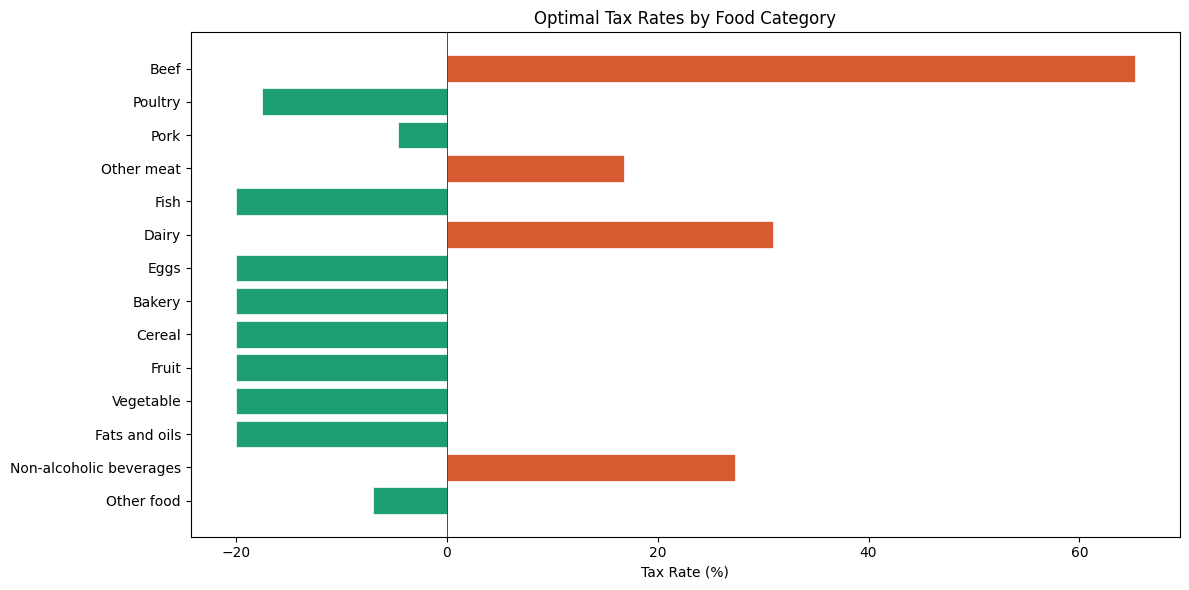

In [ ]:
# CELL 8: Optimal tax rates chart
fig = plot_optimal_taxes(opt)
plt.show()

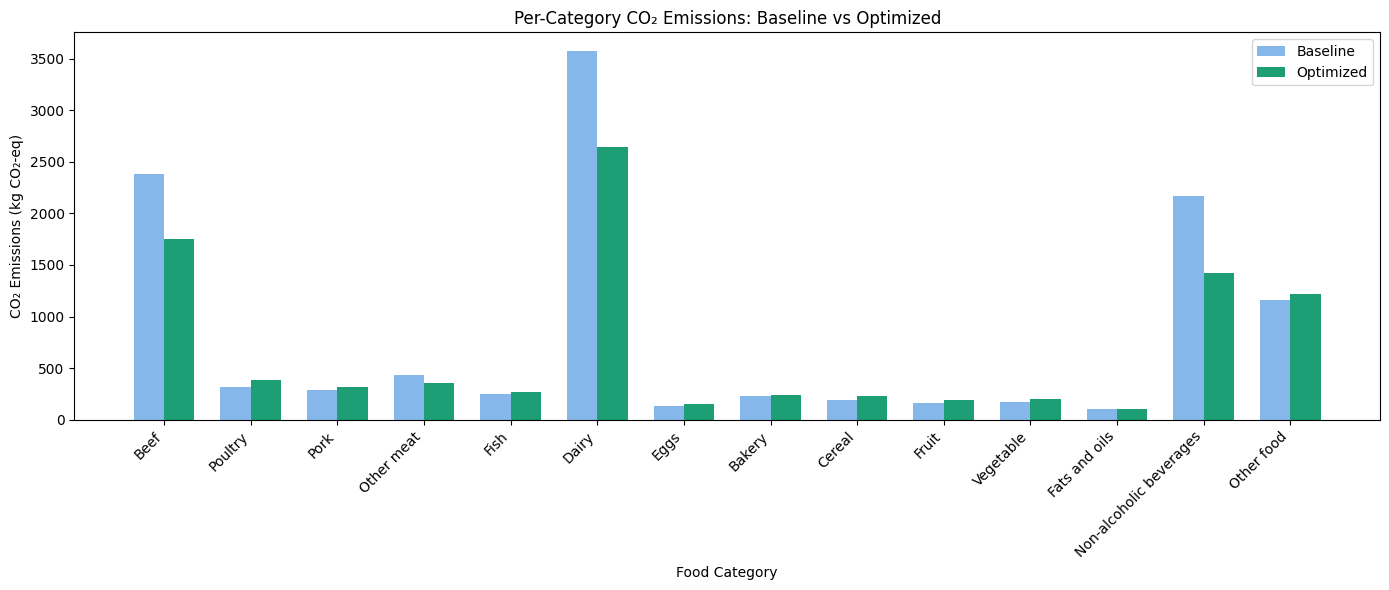

In [ ]:
# CELL 9: Emissions comparison
fig = plot_emissions_comparison(opt, model, e)
plt.show()

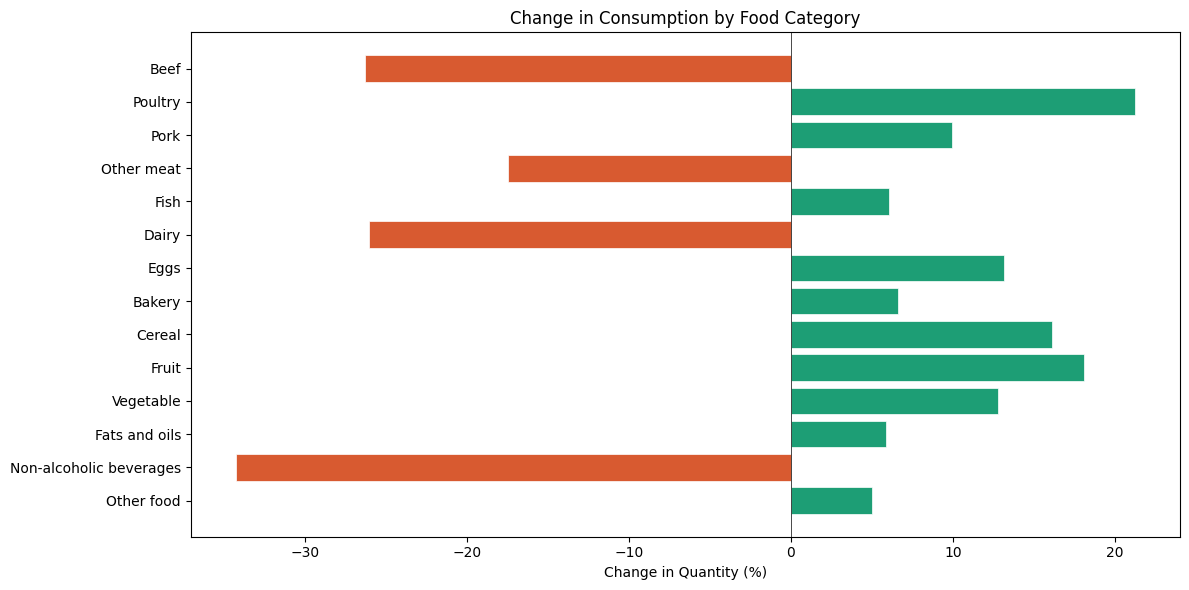

In [ ]:
# CELL 10: Quantity changes
fig = plot_quantity_changes(opt, model)
plt.show()

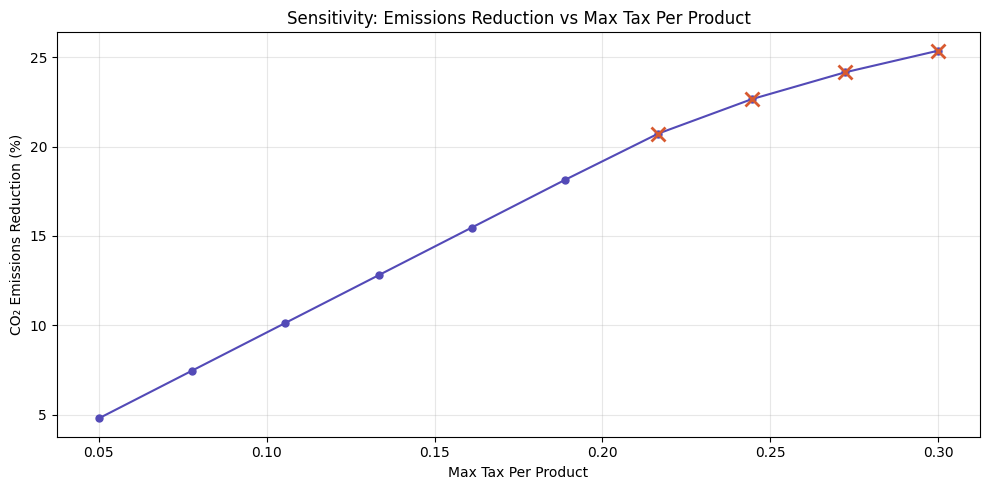

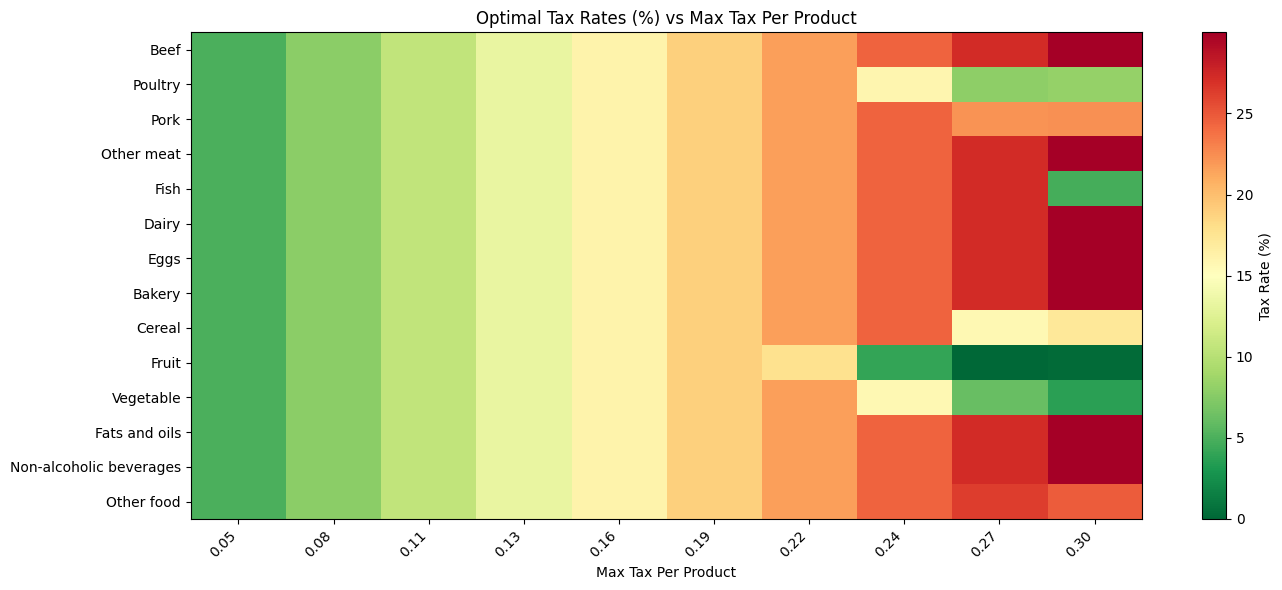

In [ ]:
# CELL 11: Sensitivity - max tax per product
tax_sweep = np.linspace(0.05, 0.30, 10)
sa_tax = sensitivity_analysis(model, e, config, 'max_tax_per_product', tax_sweep)

fig = plot_sensitivity(sa_tax, 'max_tax_per_product')
plt.show()

fig = plot_tax_heatmap(sa_tax, 'max_tax_per_product')
plt.show()

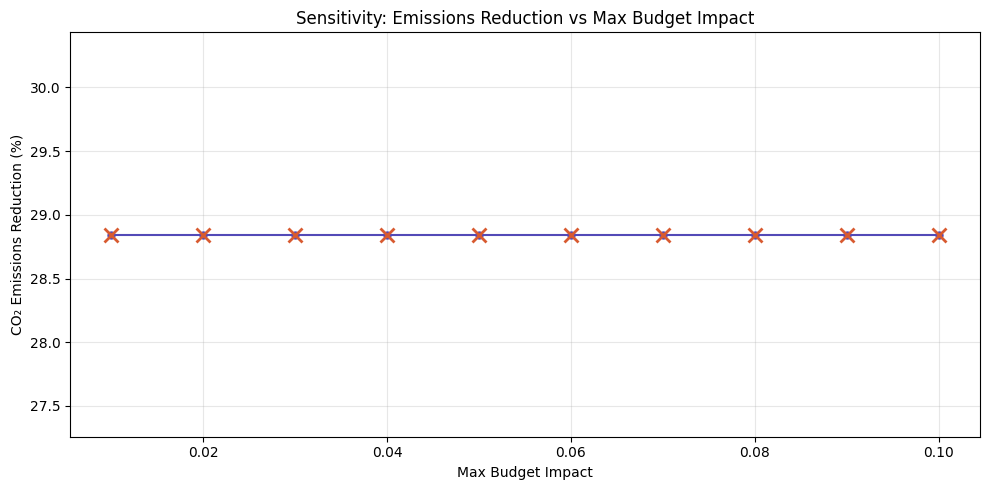

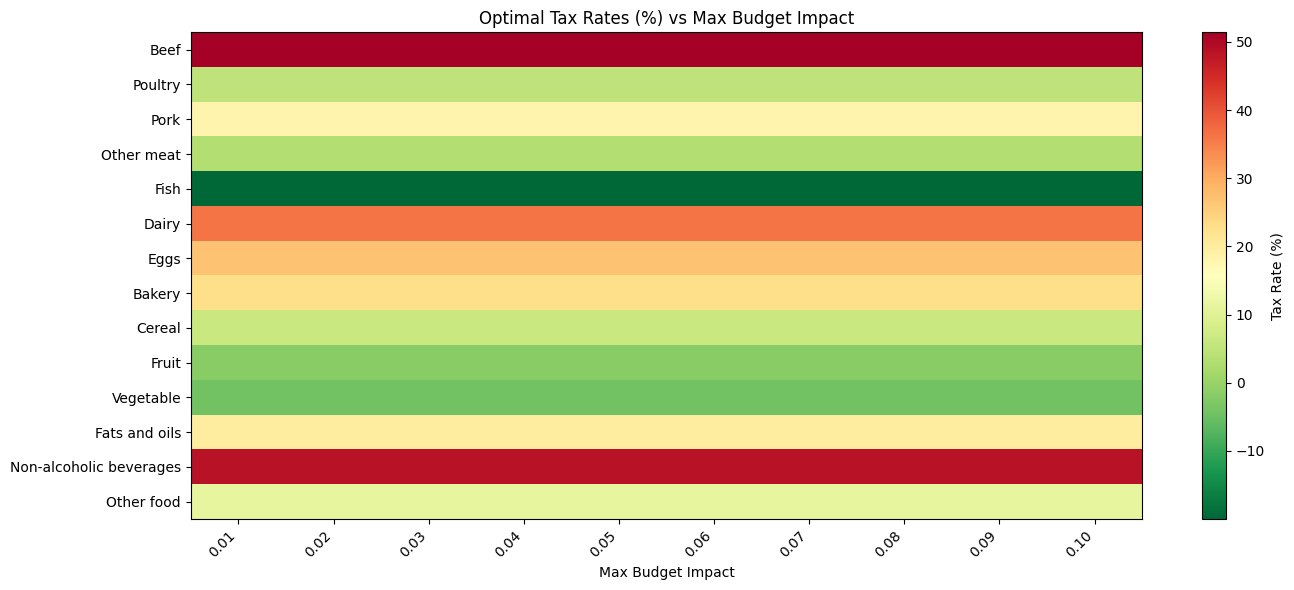

In [ ]:
# CELL 12: Sensitivity - max budget impact
budget_sweep = np.linspace(0.01, 0.10, 10)
sa_budget = sensitivity_analysis(model, e, config, 'max_budget_impact', budget_sweep)

fig = plot_sensitivity(sa_budget, 'max_budget_impact')
plt.show()

fig = plot_tax_heatmap(sa_budget, 'max_budget_impact')
plt.show()

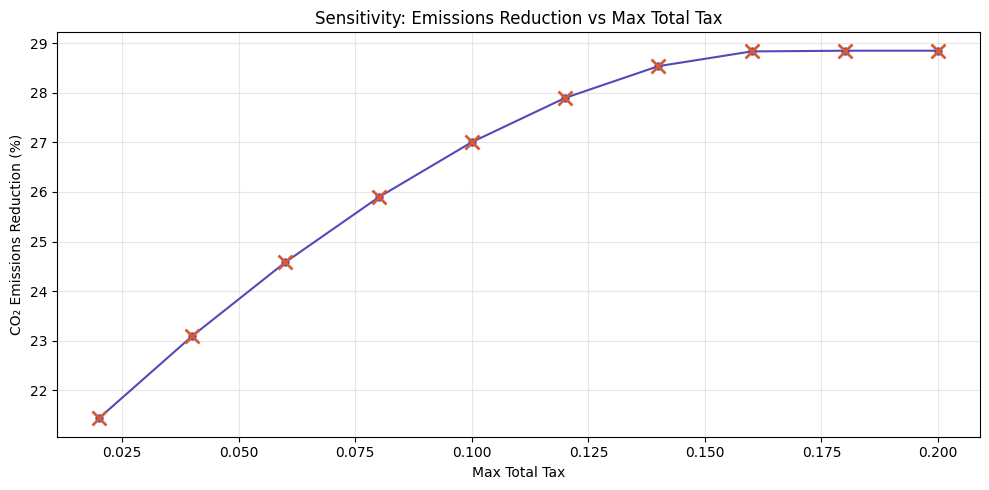

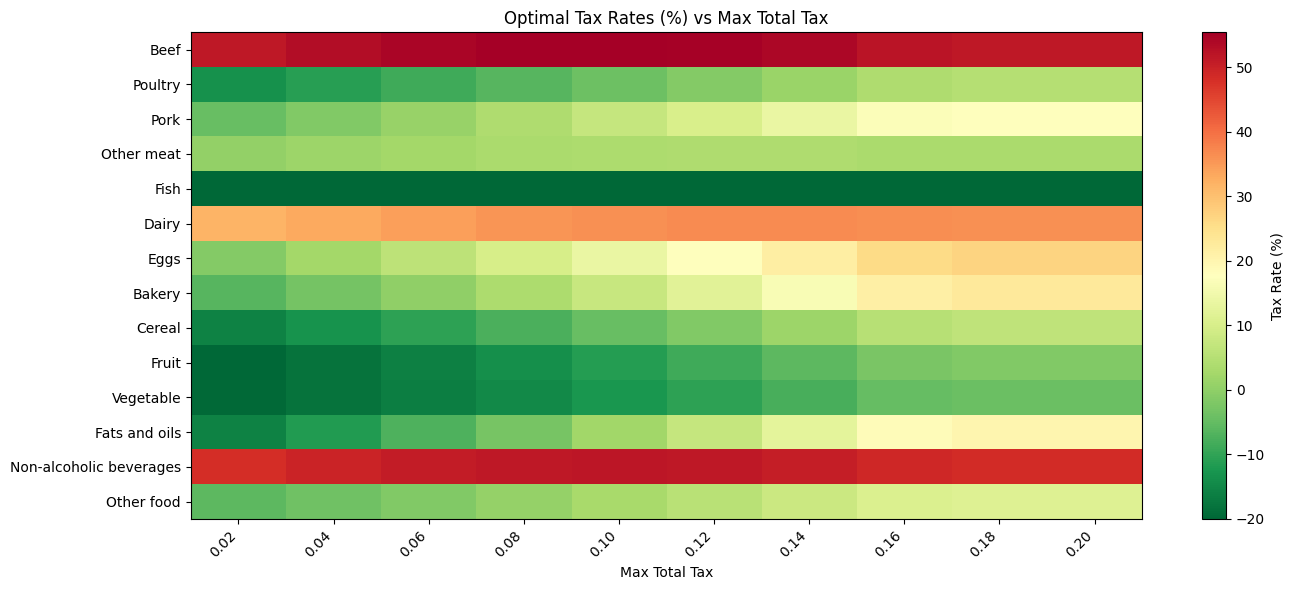

In [ ]:
# CELL 13: Sensitivity - max total tax
total_tax_sweep = np.linspace(0.02, 0.20, 10)
sa_total = sensitivity_analysis(model, e, config, 'max_total_tax', total_tax_sweep)

fig = plot_sensitivity(sa_total, 'max_total_tax')
plt.show()

fig = plot_tax_heatmap(sa_total, 'max_total_tax')
plt.show()

In [ ]:
# CELL 14 (Optional): Download results CSV
df.to_csv('optimization_results.csv', index=False)
files.download('optimization_results.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>